#### Imports and Setups

In [1]:
from pathlib import Path
from typing import TypedDict
from dotenv import load_dotenv
from rich.pretty import Pretty
from rich.markdown import Markdown
from langgraph_utils import console
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

True

#### LLM

In [2]:
def get_model(model="gemini-2.5-flash", temperature=0.7, max_output_tokens=5000):
    model = ChatGoogleGenerativeAI(
        model=model, temperature=temperature, max_output_tokens=max_output_tokens
    )
    parser = StrOutputParser()

    chain = model | parser
    return chain


model = get_model()

#### State

In [3]:
class BlogState(TypedDict):
    blog_topic: str
    blog_outline: str
    blog_content: str
    blog_summary: str

#### Node Functions

In [4]:
# topic generator
def generate_blog_topic(state: BlogState):
    prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are an astronomy research scout. Output exactly one high-interest trending astronomy topic as a single word or a strict compound noun. Do not include introductory text, punctuation, or formatting.",
            ),
            ("user", "Provide one trending astronomy topic."),
        ]
    )

    chain = prompt | model
    state["blog_topic"] = chain.invoke({})

    return state

In [5]:
# outline generator
def generate_blog_outline(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are an expert technical editor. Generate a clear, structured Markdown outline for a deep-dive blog post based on the provided topic. Ensure a logical progression from introduction to technical breakdown and conclusion.",
            ),
            ("user", "Topic: {topic}"),
        ]
    )

    chain = prompt | model
    state["blog_outline"] = chain.invoke({"topic": state["blog_topic"]})
    return state

In [6]:
# blog generator
def generate_blog_content(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are an authoritative science communicator. Expand the provided outline into a comprehensive, engaging, and scientifically accurate blog post. Use clear Markdown headers, bold text for key terms, and maintain an informative yet accessible tone.",
            ),
            ("user", "Topic: {topic}\n\nOutline:\n{outline}"),
        ]
    )

    chain = prompt | model
    state["blog_content"] = chain.invoke(
        {
            "topic": state["blog_topic"],
            "outline": state["blog_outline"],
        }
    )
    return state

In [7]:
# summary generator
def generate_blog_summary(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are an executive editor. Create a dense, highly informative 3-4 sentence summary of the provided blog content. Capture the core thesis, primary scientific insights, and final conclusion without using fluff or introductory phrases.",
            ),
            ("user", "Content:\n{content}"),
        ]
    )

    chain = prompt | model
    state["blog_summary"] = chain.invoke({"content": state["blog_content"]})
    return state

#### Init Graph

In [8]:
graph = StateGraph(BlogState)

#### Add Nodes

In [9]:
graph.add_node("generate_blog_topic", generate_blog_topic)
graph.add_node("generate_blog_outline", generate_blog_outline)
graph.add_node("generate_blog_content", generate_blog_content)
graph.add_node("generate_blog_summary", generate_blog_summary)

#### Add Edges

In [10]:
graph.add_edge(START, "generate_blog_topic")
graph.add_edge("generate_blog_topic", "generate_blog_outline")
graph.add_edge("generate_blog_outline", "generate_blog_content")
graph.add_edge("generate_blog_content", "generate_blog_summary")
graph.add_edge("generate_blog_summary", END)

#### Compilation


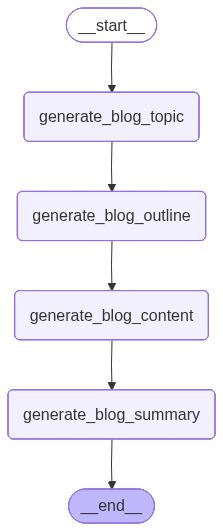

In [11]:
workflow = graph.compile()
workflow

#### Execution


In [12]:
final_state = workflow.invoke({})

In [13]:
console.print(Pretty(final_state["blog_topic"], justify="center"))

                                                 'ExoplanetAtmospheres'                                                 


In [14]:
console.print("Blog Outline:\n", Markdown(final_state["blog_outline"]))

Blog Outline:

Here's a clear, structured Markdown outline for a deep-dive blog post on "Exoplanet Atmospheres," designed for logical  
progression and technical depth.                                                                                        

------------------------------------------------------------------------------------------------------------------------

                            Unveiling Distant Skies: A Deep Dive into Exoplanet Atmospheres                             

1. Introduction: Whispers from Alien Worlds                                                                             

 • 1.1. The Allure of Distant Planets: A brief hook about humanity's fascination with worlds beyond our solar system.   
 • 1.2. What Are Exoplanet Atmospheres? Defining the gaseous envelopes surrounding planets orbiting other stars.        
 • 1.3. Why Study Them?                                                                                                 
    • 1.3.1. 

In [15]:
console.print("Blog Content:\n", Markdown(final_state["blog_content"]))

Blog Content:

                            Unveiling Distant Skies: A Deep Dive into Exoplanet Atmospheres                             

1. Introduction: Whispers from Alien Worlds                                                                             

1.1. The Allure of Distant Planets                                                                                      

For millennia, humanity has gazed at the stars, wondering if other worlds exist beyond our solar system. That ancient   
curiosity has evolved into a vibrant scientific quest, with over 5,500 exoplanets (planets orbiting stars other than our
Sun) now confirmed. Each discovery deepens our understanding of planetary diversity, but to truly grasp what these      
distant worlds are like, we must look beyond their size and orbit and peer into their most defining feature: their      
atmospheres.                                                                                                            

1.2. What Are

In [16]:
console.print("Blog Summary:\n", Markdown(final_state["blog_summary"]))

Blog Summary:

Exoplanet atmospheres are critical for understanding planetary diversity, habitability, formation, and evolution beyond 
our solar system. Scientists employ techniques like transit spectroscopy, emission spectroscopy, and direct imaging to  
analyze their composition, temperature profiles, and dynamics, revealing a vast menagerie from inflated Hot Jupiters    
with exotic chemistry to Super-Earths with hydrogen-rich envelopes. Key insights include the "Radius Valley" indicating 
atmospheric loss, the detection of vaporized metals on ultra-hot worlds, and the ongoing search for biosignatures like  
oxygen and methane in temperate, potentially habitable zones. Despite significant observational hurdles from faint      
signals, stellar activity, and obscuring clouds, continuous advancements are poised to revolutionize our understanding  
of these alien skies.                                                                                                   


In [17]:
Path("files").mkdir(exist_ok=True)

with open("./files/1-outline.md", "w") as f:
    f.write(final_state["blog_outline"])

with open("./files/2-blog_content.md", "w") as f:
    f.write(final_state["blog_content"])

with open("./files/3-blog_summary.md", "w") as f:
    f.write(final_state["blog_summary"])